## DETECCIÓN DE OUTLIERS

In [3]:
import pandas as pd
import numpy as np
from scipy import stats #para algoritmos de estadistica 
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt

In [5]:
# Carga de datos.
df = pd.read_csv("outliers.csv") #200 muestras y 2 atributos
print(df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
195 -5.114441  0.646251
196  5.631630  0.277174
197  1.552784  2.348984
198 -0.545507  1.530697
199  1.011772  4.813896

[200 rows x 2 columns]


### 1) EllipticEnvelope()

In [6]:
# Entrenamos un objeto de tipo EllipticEnvelope, que se le pasan todas las variables, no solo una (trabaja con matriz)
#deteccion de outliers en el dataframe de entrenamientos
algorithm = EllipticEnvelope(support_fraction=None, contamination=0.25, random_state=42)
outlier_method = algorithm.fit(df) #lo que hacemos es analizar la distribucion de los datos de train, para encontrar los outliers en el entramiento y poder ajsutar el modelo

# Aplicamos el método de detección de outliers entrenado sobre nuesto dataset
df_outliers = outlier_method.predict(df)
print(df_outliers) #va a indicarnos donde tenemos una serie de outliers

# Determinar la posición de los outliers
pos_outliers = np.where(df_outliers==-1)[0] #donde hay un -1 los hay
print('\nOutliers en la posición: \n', pos_outliers)

# Determinar el número de outliers
print('\nNúmero de outliers: \n', len(pos_outliers))

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición: 
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers: 
 50


In [9]:
# Definimos una función que, dado un determinado "df" y un "algorithm", devuelva la matriz y la posición de outliers
def find_outliers(df, algorithm):
    
    #Entrenamos el agoritmo
    outlier_method = algorithm.fit(df)

    #Aplicamos el merodo de deteccion de outliers
    df_outliers = outlier_method.predict(df)

    # Determinar la posición de los outliers
    pos_outliers = np.where(df_outliers==-1)[0]

    print('\nOutliers en la posición: \n', pos_outliers)

    # Determinar el número de outliers
    print('\nNúmero de outliers: \n', len(pos_outliers))

    return df_outliers, pos_outliers

### 2) Otros métodos similares

importante aprender a buscar los metodos en la documentacion https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html#sklearn.ensemble.IsolationForest

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

#ALGORITMOS
IF = IsolationForest(random_state=42) #si no se ponen parametos se meten por defecto los del link de arriba
OC_SVM = OneClassSVM(kernel='poly', degree=1, gamma='auto')
LOF = LocalOutlierFactor(n_neighbors=20, algorithm='auto', metric='euclidean',novelty=True)

df_outliers, pos_outliers = find_outliers(df, IF)
df_outliers, pos_outliers = find_outliers(df, OC_SVM)
df_outliers, pos_outliers = find_outliers(df, LOF)
# print(len(pos_outliers))


Outliers en la posición: 
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 165 166 167 168
 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186
 187 188 189 190 191 192 193 194 195 196 197 199]

Número de outliers: 
 48

Outliers en la posición: 
 [151 152 153 154 155 156 158 159 162 163 166 167 170 179 180 182 183 188
 189 190 191 194 196 197 199]

Número de outliers: 
 25

Outliers en la posición: 
 [ 37  56  89 104 110 126 131 142 150 151 152 153 155 156 158 160 161 163
 164 165 166 167 168 169 170 171 173 176 178 179 180 181 182 183 184 185
 186 187 188 189 194 195 196 197 198 199]

Número de outliers: 
 46


C:\Users\Carmen\anaconda3\envs\limpio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [14]:
# Eliminamos los outliers
new_df = df[df_outliers==1]
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
177 -4.981947  5.839675
190 -2.571455  4.423190
191 -3.316850  5.558670
192 -5.854146  5.638546
193 -5.482081  4.693717

[154 rows x 2 columns]


### 3) Box plot

limite inferior:  -1.0853060827395105
limite superior:  1.0119554520872196
Posición de outliers:  [150 153 154 157 159 160 162 165 168 169 171 172 174 175 177 178 181 184
 185 186 187 190 191 192 193 195 151 152 155 156 161 163 164 166 167 173
 176 179 180 182 188 189 196 197]
Número de outliers:  44


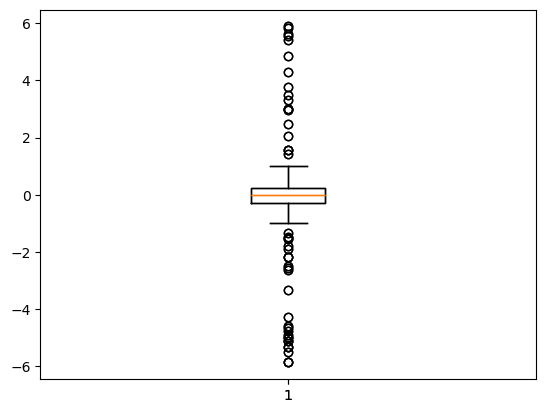

In [15]:
# Seleccionamos el atributo que vamos a medir
a = df['a'] #habria que verlo por a y por b tambien

# Seleccionamos los umbrales a partir de los cuales vamos a considerar outliers
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)
RIC = Q3 - Q1
li = Q1 - 1.5*RIC #xmin
ls = Q3 + 1.5*RIC #xmax

# Observamos los límites inferior y superior
print('limite inferior: ', li)
print('limite superior: ', ls)

# Buscamos la posición de los outliers
pos_i = np.where(a<li)[0]
pos_s = np.where(a>ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s))
print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes
prop = plt.boxplot(a)
plt.boxplot(a)
plt.show()

In [18]:
# Definir una función que, dada una columna de un dataframe, devuelva la posición de los outliers según el método box plot
import numpy as np
from scipy import stats

def find_limits_BP(variable):
    # 1. Calculamos los percentiles 25 y 75
    Q1 = stats.scoreatpercentile(variable, 25)
    Q3 = stats.scoreatpercentile(variable, 75)
    
    # 2. Calculamos el Rango Intercuartílico (RIC o IQR)
    RIC = Q3 - Q1
    
    # 3. Calculamos los límites inferior y superior
    li = Q1 - 1.5 * RIC
    ls = Q3 + 1.5 * RIC
    
    # 4. Buscamos las posiciones (índices) de los valores que están fuera de los límites
    pos_i = np.where(variable < li)[0]
    pos_s = np.where(variable > ls)[0]
    
    # 5. Concatenamos ambos arrays de posiciones
    pos_outliers = np.concatenate((pos_i, pos_s))
    
    return pos_outliers


In [19]:
# Creamos un bucle for que estime los valores outliers de cada atributo
headers = df.columns # nombre de los atributos del CSV
pos_outliers = []
for i in range(len(headers)): #aqui iremos acumulando para cada uno de los atributos, coger la variable, detectar los outliers
    variable = df[headers[i]] # Atributo 'x'
    pos_out = np.expand_dims(find_limits_BP(variable), axis=1) # Llamamos a la función que hemos creado
    pos_outliers.append(pos_out) # Lo añadimos en una lista

# Concatenamos todas las posiciones de outliers
po = np.vstack(pos_outliers) #nos debemos quedar con los outliers juntos porque puede ser que para valores distintos este

# Vemos las posiciones de todos los outliers
pos_out = np.unique(po)
print('Posiciones de outliers: ', pos_out)

# Observamos el número de outliers
print('Numero de outliers: ', len(pos_out))

Posiciones de outliers:  [104 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199]
Numero de outliers:  51


##### Este cuaderno de Jupyter explica diferentes técnicas para la **detección y eliminación de *outliers*** (valores atípicos) en un conjunto de datos utilizando Python. Un *outlier* es una observación que se aleja significativamente del resto de los datos, lo que puede distorsionar los análisis estadísticos o el entrenamiento de modelos de Machine Learning.

El archivo se divide en tres enfoques principales:

---

## 1. Métodos Multivariantes (Scikit-Learn)

Estos algoritmos analizan todas las variables del conjunto de datos a la vez para identificar puntos que no encajan en la distribución global.

* **`EllipticEnvelope`**: Asume que los datos normales siguen una distribución de tipo elíptico (gaussiana multivariante). En el código, se configura con una `contamination=0.25`, lo que significa que esperamos que el 25% de los datos sean atípicos.
* **`IsolationForest`**: Utiliza una estructura de árboles de decisión. Se basa en la idea de que los valores atípicos son más fáciles de "aislar" (requieren menos divisiones en el árbol) que los puntos normales.
* **`OneClassSVM`**: Un algoritmo que intenta aprender una frontera que envuelva a los puntos normales, dejando fuera a los que se alejan demasiado.
* **`LocalOutlierFactor` (LOF)**: Mide la densidad local de un punto comparada con la de sus vecinos. Un punto con densidad mucho menor que sus vecinos se considera un *outlier*.

En estos métodos, el programa devuelve un array donde **1** indica un dato normal y **-1** indica un *outlier*.

---

## 2. Método Estadístico: Box Plot (Diagrama de Caja)

Este enfoque es **univariante**, es decir, analiza cada columna o atributo por separado. Utiliza el Rango Intercuartílico ( o ) para establecer límites:

1. Calcula el percentil 25 () y el 75 ().
2. Define el .
3. Establece barreras:
* **Límite Superior**: .
* **Límite Inferior**: .



Cualquier valor fuera de este rango se marca como atípico.

---

## 3. Limpieza de Datos

Una vez identificados los índices de los valores extraños, el cuaderno muestra cómo eliminarlos para crear un "dataset limpio":

```python
# Filtra el DataFrame original dejando solo los valores marcados como 1 (normales)
new_df = df[df_outliers==1]

```

Esto resulta en un nuevo DataFrame (`new_df`) que, en el ejemplo del código, pasa de tener 200 muestras originales a 154 tras aplicar la limpieza.

¿Te gustaría que te ayude a visualizar los resultados de estos diferentes métodos en un gráfico comparativo?